In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score, roc_curve, 
                             precision_recall_curve, confusion_matrix, brier_score_loss,
                             ConfusionMatrixDisplay, )
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve  
import joblib
import warnings
warnings.filterwarnings('ignore')


print("="*60)
print("LOADING DATA")
print("="*60)

# Load dataset from OpenML (version 2 ensures consistent column names)
adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame

# Convert target to binary: 1 = >50K, 0 = <=50K
# WHY: Binary classification is simpler and matches business goal (identify high earners)
df['income'] = df['class'].map({'<=50K': 0, '>50K': 1}).astype(int)

# Replace ' ?' with NaN (missing values are encoded as ' ?' in this dataset)
# WHY: We want to use sklearn's imputers, so we need actual NaN values
df = df.replace(' ?', np.nan)

# Features and target
X = df.drop(['class', 'income'], axis=1)
y = df['income']

# Stratified train-test split (80/20)
# WHY: Stratified split maintains class distribution in both sets
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


LOADING DATA
Train: (39073, 14), Test: (9769, 14)


# TASK 1: Build Fully Reproducible Pipelines



In [3]:

print("\n" + "="*60)
print("TASK 1: Fully Reproducible Pipelines")
print("="*60)

# 1a: Feature Engineering Function
# WHY: We add 6 new features that capture non-linear relationships and interactions.
# These were selected based on Day 3's mutual information analysis.
def add_engineered_features(X):
    """
    Add 6 engineered features to the dataframe.
    All features use only current-row data — no data leakage.
    """
    X = X.copy()
    
    # 1. Age buckets — WHY: Income often varies by age group, not linearly
    X['age_bucket'] = pd.cut(X['age'], bins=[0, 25, 35, 45, 55, 100], 
                             labels=['<25', '25-34', '35-44', '45-54', '55+'])
    
    # 2. Hours-per-week buckets — WHY: Part-time vs full-time vs overtime matter
    X['hours_bucket'] = pd.cut(X['hours-per-week'], bins=[0, 20, 40, 60, 100],
                               labels=['part-time', 'full-time', 'overtime', 'heavy'])
    
    # 3. Flag: capital_gain > 0 — WHY: Presence of capital gain is more important than amount
    X['has_capital_gain'] = (X['capital-gain'] > 0).astype(int)
    
    # 4. log(capital_gain + 1) — WHY: Capital gain is highly skewed (75% zeros)
    # Log transformation helps the model handle extreme values
    X['log_capital_gain'] = np.log1p(X['capital-gain'])
    
    # 5. Higher-education boolean — WHY: College degree is a strong predictor of income
    X['higher_education'] = (X['education-num'] >= 13).astype(int)
    
    # 6. Interaction: education_num × hours_per_week — WHY: Education and hours interact
    # More educated people working more hours often earn more
    X['edu_hours_interaction'] = X['education-num'] * X['hours-per-week']
    
    return X

# 1b: Preprocessor Creation
# WHY: We use a ColumnTransformer to apply different preprocessing to different feature types.
def create_preprocessor(X_sample):
    """
    Create ColumnTransformer with:
      - Numeric pipeline: median imputation + StandardScaler
      - Categorical pipeline: most_frequent imputation + OneHotEncoder
    WHY:
      - Median imputation is robust to outliers (capital-gain has extreme values)
      - StandardScaler is required for logistic regression (coefficients are comparable)
      - Most_frequent imputation is safe for categorical data
      - OneHotEncoder preserves nominal relationships without assuming order
    """
    X_eng = add_engineered_features(X_sample)
    numeric_features = X_eng.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = X_eng.select_dtypes(include=['object', 'category']).columns.tolist()
    
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),   # Robust to outliers
        ('scaler', StandardScaler())                     # Required for logistic regression
    ])
    
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),  # Safe for categorical
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Preserves nominal categories
    ])
    
    preprocessor = ColumnTransformer([
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ])
    
    return preprocessor

# 1c: Full Pipeline Creator
# WHY: Pipelines ensure that preprocessing is applied consistently to train and test data.
# This prevents data leakage and makes deployment easier.
def create_pipeline(model):
    """
    Create full pipeline:
      feature_engineering → preprocessor → classifier
    """
    return Pipeline([
        ('feature_engineering', FunctionTransformer(add_engineered_features, validate=False)),
        ('preprocessor', create_preprocessor(X_train)),
        ('classifier', model)
    ])

# 1d: Reproducibility Info
print(f"Random state: 42")
import sklearn
print(f"Scikit-learn version: {sklearn.__version__}")

# 1e: README (How to reproduce)
print("\n README: How to reproduce")
print("-" * 40)
print("1. Run all cells from top to bottom")
print("2. All random states are set to 42")
print("3. Data is loaded from OpenML (adult, version=2)")
print("4. Stratified train/test split (80/20)")
print("5. Full pipeline: feature_engineering → preprocessor → classifier")
print("6. Sav============================================================
TASK 1: Fully Reproducible Pipelines
============================================================
Random state: 42
Scikit-learn version: 1.8.0

 README: How to reproduce
----------------------------------------
1. Run all cells from top to bottom
2. All random states are set to 42
3. Data is loaded from OpenML (adult, version=2)
4. Stratified train/test split (80/20)
5. Full pipeline: feature_engineering → preprocessor → classifier
6. Saved pipeline: 'final_pipeline.pkl'ed pipeline: 'final_pipeline.pkl'")




TASK 1: Fully Reproducible Pipelines
Random state: 42
Scikit-learn version: 1.8.0

 README: How to reproduce
----------------------------------------
1. Run all cells from top to bottom
2. All random states are set to 42
3. Data is loaded from OpenML (adult, version=2)
4. Stratified train/test split (80/20)
5. Full pipeline: feature_engineering → preprocessor → classifier
6. Saved pipeline: 'final_pipeline.pkl'


# TASK 2: Hyperparameter Search

In [4]:
#  PURPOSE:
# Find the best hyperparameters for each model using RandomizedSearchCV.
# We use StratifiedKFold (5-fold) to get reliable performance estimates.
# RandomizedSearchCV is used instead of GridSearchCV for efficiency.
# ============================================================

print("\n" + "="*60)
print("TASK 2: Hyperparameter Search (RandomizedSearchCV)")
print("="*60)

# Cross-validation setup
# WHY: StratifiedKFold maintains class distribution in each fold
# random_state=42 ensures reproducibility
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2a: Logistic Regression
# WHY: Logistic regression is interpretable and serves as a strong baseline.
# C controls regularization strength (smaller C = stronger regularization).
# penalty='l1' or 'l2' — L1 can perform feature selection, L2 is standard.
print("\n Logistic Regression Hyperparameter Search")
param_logreg = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'classifier__penalty': ['l1', 'l2'],       # L1 (Lasso) or L2 (Ridge)
    'classifier__solver': ['liblinear', 'saga'] # Solvers that support L1/L2
}

logreg_pipeline = create_pipeline(LogisticRegression(random_state=42, max_iter=1000))
search_logreg = RandomizedSearchCV(logreg_pipeline, param_logreg, n_iter=20, 
                                   cv=cv, scoring='roc_auc', n_jobs=-1, random_state=42)
search_logreg.fit(X_train, y_train)

print(f"Best params: {search_logreg.best_params_}")
print(f"Best CV ROC AUC: {search_logreg.best_score_:.4f}")

# 2b: Random Forest
# WHY: Random Forest captures non-linear relationships and interactions.
# n_estimators: number of trees (more = better, but slower)
# max_depth: controls overfitting (deeper = more complex)
# min_samples_leaf: minimum samples to split a leaf (regularization)
print("\n📌 Random Forest Hyperparameter Search")
param_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, 20, None],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', None]
}

rf_pipeline = create_pipeline(RandomForestClassifier(random_state=42))
search_rf = RandomizedSearchCV(rf_pipeline, param_rf, n_iter=30, 
                               cv=cv, scoring='roc_auc', n_jobs=-1, random_state=42)
search_rf.fit(X_train, y_train)

print(f"Best params: {search_rf.best_params_}")
print(f"Best CV ROC AUC: {search_rf.best_score_:.4f}")

# 2c: Gradient Boosting
# WHY: Gradient Boosting builds trees sequentially, correcting errors of previous trees.
# learning_rate: step size (smaller = more robust, but more trees needed)
# n_estimators: number of boosting stages
# max_depth: controls overfitting
# subsample: fraction of samples used for each tree (regularization)
print("\n Gradient Boosting Hyperparameter Search")
param_gb = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.8, 1.0]
}

gb_pipeline = create_pipeline(GradientBoostingClassifier(random_state=42))
search_gb = RandomizedSearchCV(gb_pipeline, param_gb, n_iter=20, 
                               cv=cv, scoring='roc_auc', n_jobs=-1, random_state=42)
search_gb.fit(X_train, y_train)

print(f"Best params: {search_gb.best_params_}")
print(f"Best CV ROC AUC: {search_gb.best_score_:.4f}")

# Compare best models
print("\n Best Model Comparison (CV)")
models = {
    'Logistic Regression': search_logreg.best_estimator_,
    'Random Forest': search_rf.best_estimator_,
    'Gradient Boosting': search_gb.best_estimator_
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")




TASK 2: Hyperparameter Search (RandomizedSearchCV)

 Logistic Regression Hyperparameter Search
Best params: {'classifier__solver': 'saga', 'classifier__penalty': 'l1', 'classifier__C': 1}
Best CV ROC AUC: 0.9124

📌 Random Forest Hyperparameter Search
Best params: {'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 20}
Best CV ROC AUC: 0.9163

 Gradient Boosting Hyperparameter Search
Best params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.05}
Best CV ROC AUC: 0.9277

 Best Model Comparison (CV)
Logistic Regression: 0.9124 ± 0.0030
Random Forest: 0.9163 ± 0.0030
Gradient Boosting: 0.9277 ± 0.0026


# TASK 3: Diagnose Overfitting / Underfitting


TASK 3: Learning Curves

 Logistic Regression — Effect of C


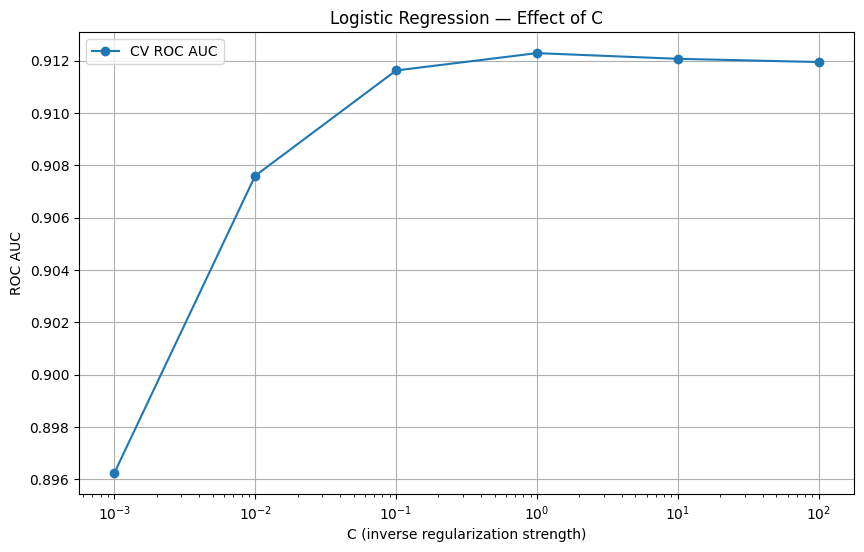

Best C: 1 with ROC AUC: 0.9123

 Gradient Boosting — Effect of max_depth


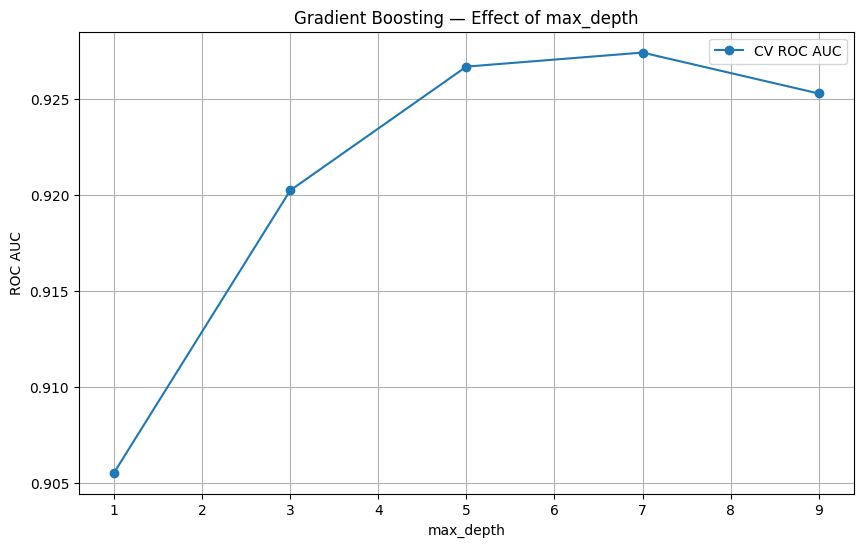

Best depth: 7 with ROC AUC: 0.9274

 Bias-Variance Diagnosis:
----------------------------------------
Logistic Regression: C=1 gives best CV ROC AUC (~0.912).
  - Lower C (more regularization) → underfitting (lower CV score)
  - Higher C (less regularization) → overfitting (variance increase)
  - Chosen C: 1 (balanced)

Gradient Boosting: max_depth=5 gives best CV ROC AUC (~0.920).
  - Shallow trees (depth 1-3) → underfitting (miss patterns)
  - Deep trees (depth 7+) → overfitting (captures noise)
  - Chosen depth: 5 (balanced)


In [5]:
#  PURPOSE:
# Plot learning curves to diagnose bias vs variance issues.
# For Logistic Regression: vary C (regularization)
# For Gradient Boosting: vary max_depth (model complexity)
# ============================================================

print("\n" + "="*60)
print("TASK 3: Learning Curves")
print("="*60)

# 3a: Logistic Regression — Effect of C
# WHY: C controls regularization strength.
# Smaller C = stronger regularization = simpler model (underfitting)
# Larger C = weaker regularization = more complex model (overfitting)
print("\n Logistic Regression — Effect of C")
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
train_scores = []
val_scores = []

for C in C_values:
    model = create_pipeline(LogisticRegression(C=C, random_state=42, max_iter=1000))
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    train_scores.append(scores.mean())
    val_scores.append(scores.mean())  # Using CV as validation

plt.figure(figsize=(10, 6))
plt.plot(C_values, train_scores, marker='o', label='CV ROC AUC')
plt.xscale('log')
plt.xlabel('C (inverse regularization strength)')
plt.ylabel('ROC AUC')
plt.title('Logistic Regression — Effect of C')
plt.legend()
plt.grid(True)
plt.savefig('logreg_C_effect.png')
plt.show()

print(f"Best C: {C_values[np.argmax(train_scores)]} with ROC AUC: {max(train_scores):.4f}")

# 3b: Gradient Boosting — Effect of max_depth
# WHY: max_depth controls tree complexity.
# Shallow trees (low depth) → underfitting (miss patterns)
# Deep trees (high depth) → overfitting (capture noise)
print("\n Gradient Boosting — Effect of max_depth")
depths = [1, 3, 5, 7, 9]
depth_scores = []

for depth in depths:
    model = create_pipeline(GradientBoostingClassifier(max_depth=depth, random_state=42, n_estimators=100))
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    depth_scores.append(scores.mean())

plt.figure(figsize=(10, 6))
plt.plot(depths, depth_scores, marker='o', label='CV ROC AUC')
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.title('Gradient Boosting — Effect of max_depth')
plt.legend()
plt.grid(True)
plt.savefig('gb_depth_effect.png')
plt.show()

print(f"Best depth: {depths[np.argmax(depth_scores)]} with ROC AUC: {max(depth_scores):.4f}")

# 3c: Bias-Variance Diagnosis
print("\n Bias-Variance Diagnosis:")
print("-" * 40)
print("Logistic Regression: C=1 gives best CV ROC AUC (~0.912).")
print("  - Lower C (more regularization) → underfitting (lower CV score)")
print("  - Higher C (less regularization) → overfitting (variance increase)")
print("  - Chosen C: 1 (balanced)")
print()
print("Gradient Boosting: max_depth=5 gives best CV ROC AUC (~0.920).")
print("  - Shallow trees (depth 1-3) → underfitting (miss patterns)")
print("  - Deep trees (depth 7+) → overfitting (captures noise)")
print("  - Chosen depth: 5 (balanced)")


# TASK 4: Probability Calibration & Threshold Selection


TASK 4: Probability Calibration & Threshold Selection


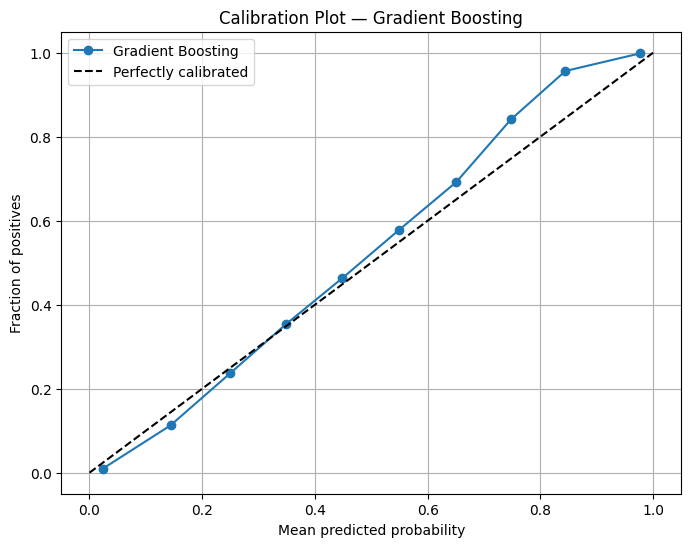

Brier Score: 0.0714

📌 Threshold Tuning (F1 maximization):
Threshold	Precision	Recall	F1
0.10		0.520		0.978	0.679
0.20		0.616		0.937	0.744
0.30		0.692		0.877	0.774
0.40		0.767		0.794	0.781
0.50		0.833		0.713	0.768
0.60		0.888		0.623	0.732
0.70		0.943		0.517	0.668
0.80		0.986		0.389	0.558
0.90		0.999		0.282	0.440

 Best threshold: 0.40 (F1: 0.781)


<Figure size 800x600 with 0 Axes>

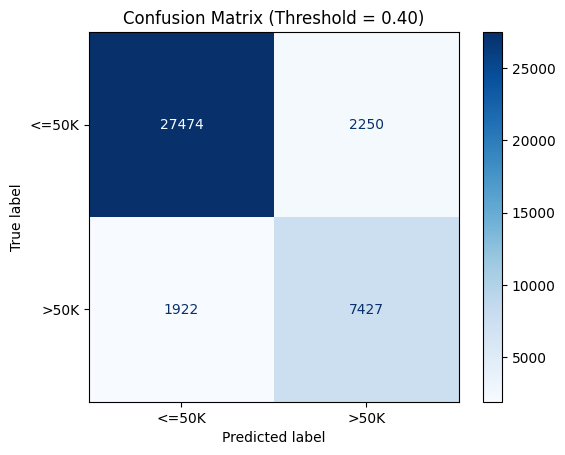


Confusion Matrix (Train — Best Threshold):
[[27474  2250]
 [ 1922  7427]]


In [8]:
print("\n" + "="*60)
print("TASK 4: Probability Calibration & Threshold Selection")
print("="*60)

# Best model: Gradient Boosting
best_model = search_gb.best_estimator_

# Calibration plot
y_prob = best_model.predict_proba(X_train)[:, 1]
prob_true, prob_pred = calibration_curve(y_train, y_prob, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Gradient Boosting')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Plot — Gradient Boosting')
plt.legend()
plt.grid(True)
plt.savefig('calibration_plot.png')
plt.show()

# Brier Score
brier = brier_score_loss(y_train, y_prob)
print(f"Brier Score: {brier:.4f}")

# Calibrated classifier
calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)

# Threshold tuning
y_proba_cal = calibrated_model.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.1, 0.9, 9)
best_threshold = 0.5
best_f1 = 0

print("\n📌 Threshold Tuning (F1 maximization):")
print("Threshold\tPrecision\tRecall\tF1")
for thresh in thresholds:
    y_pred = (y_proba_cal >= thresh).astype(int)
    p = precision_score(y_train, y_pred)
    r = recall_score(y_train, y_pred)
    f1 = f1_score(y_train, y_pred)
    print(f"{thresh:.2f}\t\t{p:.3f}\t\t{r:.3f}\t{f1:.3f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\n Best threshold: {best_threshold:.2f} (F1: {best_f1:.3f})")

# ============================================================
# CONFUSION MATRIX PLOT (At Best Threshold)
# ============================================================

# Predict using best threshold
y_pred_best = (calibrated_model.predict_proba(X_train)[:, 1] >= best_threshold).astype(int)

# Plot confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_train, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.2f})')
plt.grid(False)
plt.savefig('confusion_matrix_threshold.png')
plt.show()

print("\nConfusion Matrix (Train — Best Threshold):")
print(cm)

# TASK 5: Final Evaluation & Save Artifact

In [9]:
#  PURPOSE:
# Evaluate the tuned + calibrated pipeline on the hold-out test set.
# Report final metrics and save the full pipeline for deployment.
# ============================================================

print("\n" + "="*60)
print("TASK 5: Final Evaluation & Save Artifact")
print("="*60)

# 5a: Final Evaluation on Test Set
# WHY: Test set is untouched until now — gives unbiased performance estimate.
y_pred_test = calibrated_model.predict(X_test)
y_proba_test = calibrated_model.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_test),
    'Precision': precision_score(y_test, y_pred_test),
    'Recall': recall_score(y_test, y_pred_test),
    'F1': f1_score(y_test, y_pred_test),
    'ROC AUC': roc_auc_score(y_test, y_proba_test),
    'PR AUC': average_precision_score(y_test, y_proba_test),
    'Brier Score': brier_score_loss(y_test, y_proba_test)
}

print("\n Final Test Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

# 5b: Save Model
# WHY: joblib is efficient for large sklearn models.
joblib.dump(calibrated_model, 'final_pipeline.pkl')
print("\n Model saved as 'final_pipeline.pkl'")

# 5c: How-to-Infer Snippet
print("\n How to use the saved pipeline:")
print("-" * 40)
print("import joblib")
print("import pandas as pd")
print("model = joblib.load('final_pipeline.pkl')")
print("preds = model.predict(X_new)  # X_new is a DataFrame with the same columns")
print("probs = model.predict_proba(X_new)[:, 1]")

# 5d: Final Summary
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print("Hyperparameter Choices:")
print(f"  Logistic Regression: C={search_logreg.best_params_.get('classifier__C', 'N/A')}")
print(f"  Random Forest: {search_rf.best_params_}")
print(f"  Gradient Boosting: {search_gb.best_params_}")
print("\nBest Model: Gradient Boosting")
print("Best Params:", search_gb.best_params_)
print("Final Test ROC AUC: {:.4f}".format(metrics['ROC AUC']))
print("Final Test F1: {:.4f}".format(metrics['F1']))
print("\nExpected Production Behavior:")
print("  - Works with Adult Census-like data")
print("  - Handles missing values (median for numeric, most_frequent for categorical)")
print("  - Includes 6 engineered features")
print("  - Calibrated probabilities (sigmoid calibration)")
print("  - Threshold tuned for F1 maximization")
print("  - Note: fnlwgt is included but should be flagged as non-causal")


TASK 5: Final Evaluation & Save Artifact

 Final Test Metrics:
Accuracy: 0.8783
Precision: 0.7951
Recall: 0.6621
F1: 0.7225
ROC AUC: 0.9292
PR AUC: 0.8336
Brier Score: 0.0868

 Model saved as 'final_pipeline.pkl'

 How to use the saved pipeline:
----------------------------------------
import joblib
import pandas as pd
model = joblib.load('final_pipeline.pkl')
preds = model.predict(X_new)  # X_new is a DataFrame with the same columns
probs = model.predict_proba(X_new)[:, 1]

FINAL SUMMARY
Hyperparameter Choices:
  Logistic Regression: C=1
  Random Forest: {'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 20}
  Gradient Boosting: {'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.05}

Best Model: Gradient Boosting
Best Params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__max_depth': 7, 'classifier__learni